# Visualization

Two complementary views of a model, both reading from the same training run:

- **Plotting** (`PlotVisualizer`) — how *values* evolve over training: loss, accuracy, and the distributions of weights and gradients.
- **Graphing** (`GraphVisualizer`) — the *structure* of a single forward/backward pass: the computation graph, the same graph with layers boxed, and the collapsed architecture.

## Setup

Train a small classifier on a synthetic 3-class dataset, recording history as we go. The `Recorder` collects two kinds of data: scalars handed in each step (`loss`, `acc`), and the parameters/activations harvested from the graph by `capture()` after each `backward()`.

In [1]:
%matplotlib inline

from random import Random

from babygrad.metrics import accuracy
from babygrad.nn import CCE, SGD, Linear, ReLU, Sequential, Softmax
from babygrad.recorder import Recorder
from babygrad.tensor import Tensor
from babygrad.viz.graph import GraphVisualizer
from babygrad.viz.plot import PlotVisualizer

In [2]:
# synthetic data: each class has its features shifted around a different mean
rng = Random(0)
samples = 24
features, targets = [], []
for i in range(samples):
    label = i % 3
    features.extend(rng.gauss(label, 0.5) for _ in range(4))
    onehot = [0.0, 0.0, 0.0]
    onehot[label] = 1.0
    targets.extend(onehot)

x = Tensor(features, shape=(samples, 4))
y = Tensor(targets, shape=(samples, 3))

model = Sequential([Linear(4, 16), ReLU(), Linear(16, 3), Softmax()])
optimizer = SGD(model.parameters(), lr=0.3)
criterion = CCE()
recorder = Recorder()

for step in range(40):
    recorder.set_step(step)
    optimizer.zero_grad()
    y_pred = model.forward(x)
    loss = criterion.forward(y, y_pred)
    recorder.record("loss", loss.data[0])
    recorder.record("acc", accuracy(y, y_pred))
    loss.backward()
    recorder.capture(loss)
    optimizer.step()

round(recorder.history["loss"][0], 4), round(recorder.history["loss"][39], 4)

(1.098, 0.361)

## Plotting training history

`PlotVisualizer` is constructed with the recorded history and renders it post-hoc. It never touches the model — it only consumes the plain `tag -> step -> value` data the `Recorder` collected.

### Loss and accuracy over steps

Scalar series, one value per step.

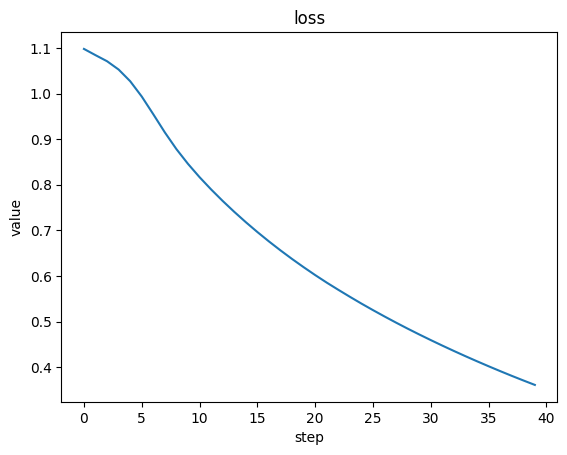

In [3]:
viz = PlotVisualizer(recorder.history)
viz.plot_scalar("loss")

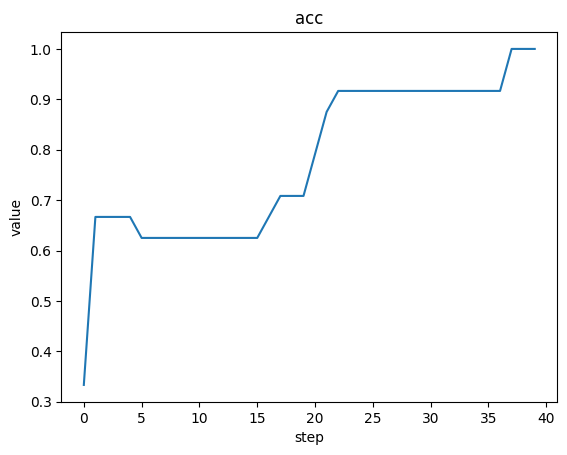

In [4]:
viz.plot_scalar("acc")

### Weight and gradient distributions

A *ridge* plot stacks one histogram per step (earliest at the bottom), so you can watch a distribution drift as training proceeds. Gradients are heavy-tailed, so we clip the bins to the 1st-99th percentile and let outliers pile into the edge bins.

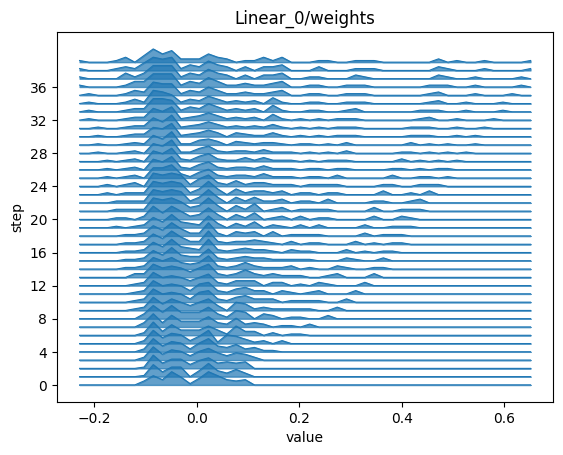

In [5]:
viz.plot_ridge("Linear_0/weights")

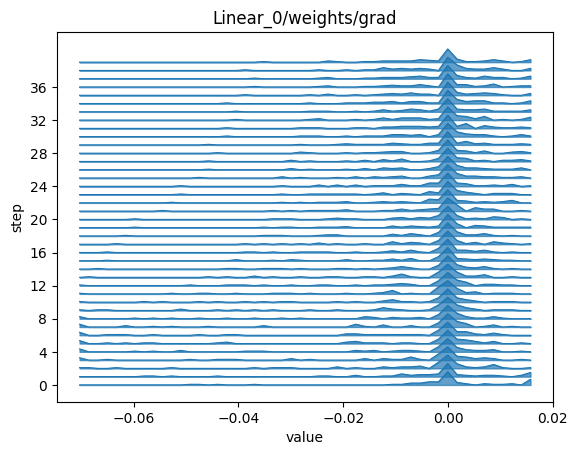

In [6]:
viz.plot_ridge("Linear_0/weights/grad", clip_quantiles=(0.01, 0.99))

## Graphing the network

`GraphVisualizer` walks the autograd graph backward from a tensor (here, the loss) into a neutral bipartite structure — tensors and ops are both nodes — then draws it. We build it from a fresh forward pass so the graph reflects the trained weights.

In [7]:
y_pred = model.forward(x)
loss = criterion.forward(y, y_pred)
graph = GraphVisualizer(loss)

### Computation graph

Every operation is its own node (red ellipse) sitting between its input and output tensors (boxes). Dashed edges feed *into* an op; solid edges carry its result out. Node colours encode role: input/target (amber), parameters (cyan), op results (grey), layer outputs (blue), loss (navy).

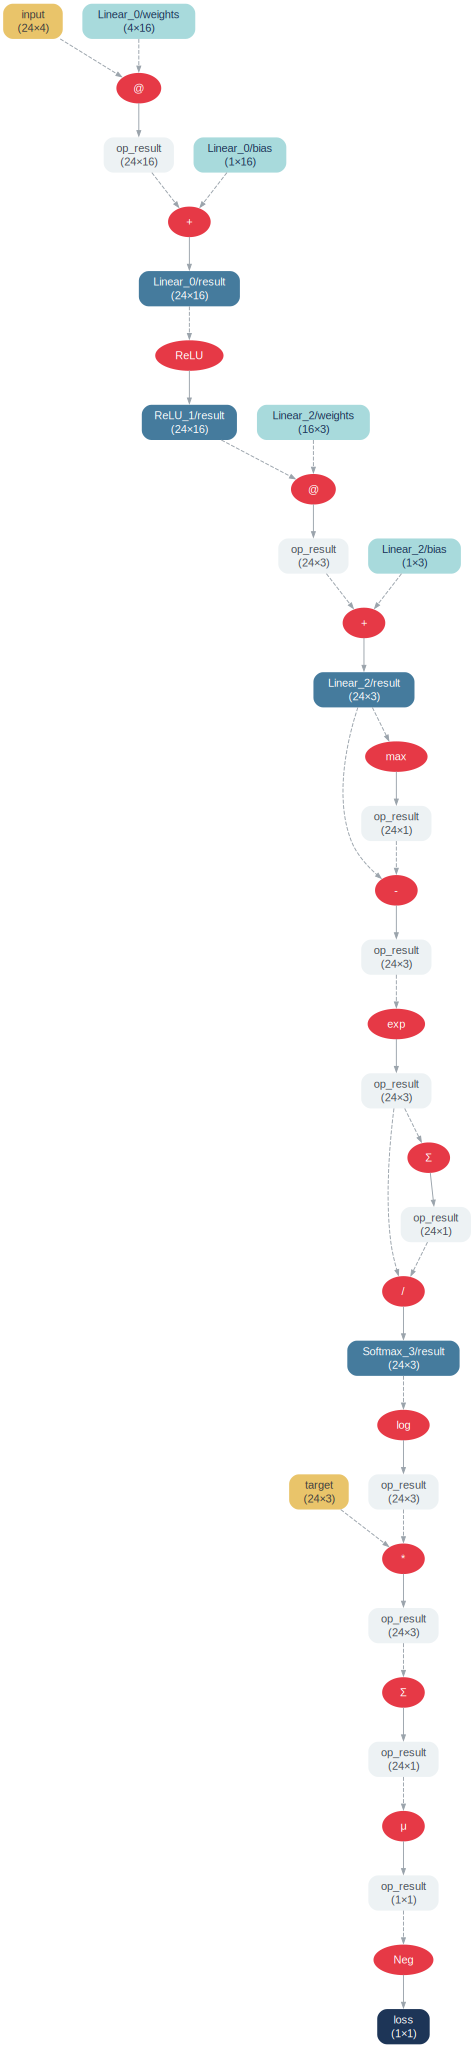

In [8]:
graph.draw_computation()

### Combined

The same graph, with every layer's nodes wrapped in a titled cluster box (its scope). Input and target sit outside the boxes — they enter the computation rather than belonging to any layer.

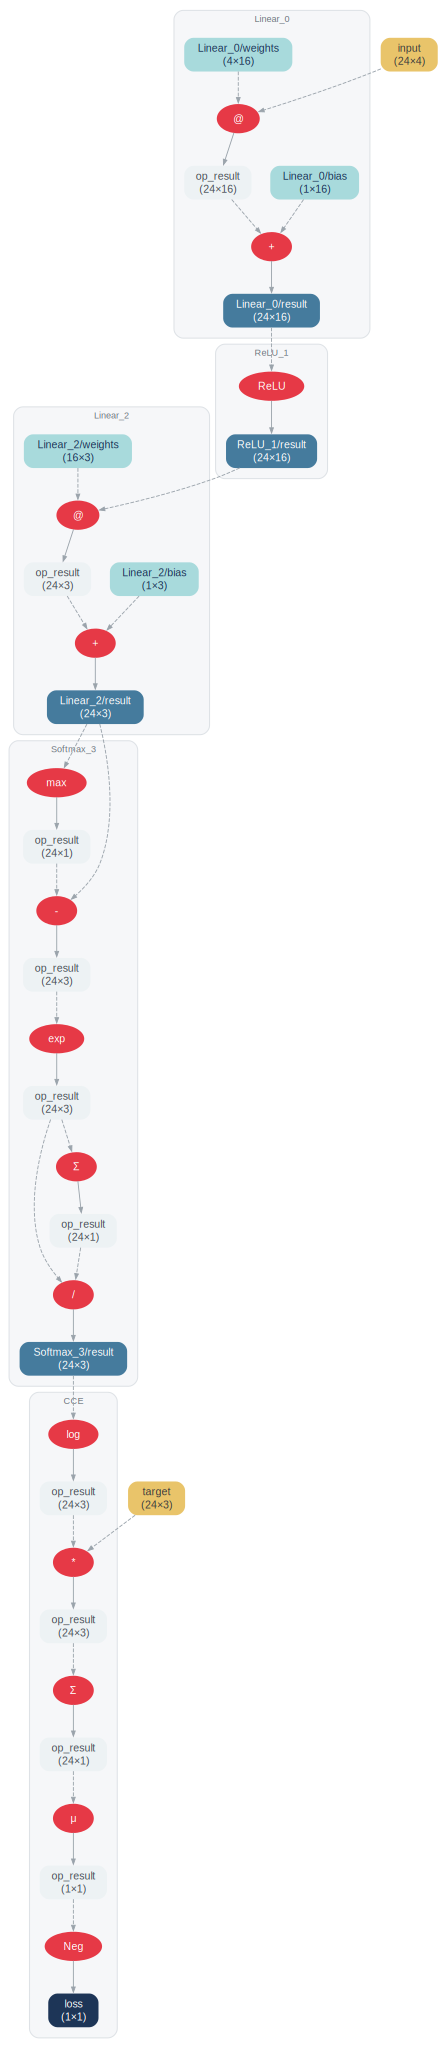

In [9]:
graph.draw_combined()

### Architecture

Each layer scope collapsed to a single box, with edges labelled by the shape of the tensor crossing between layers — the data-shape story of the whole network at a glance.

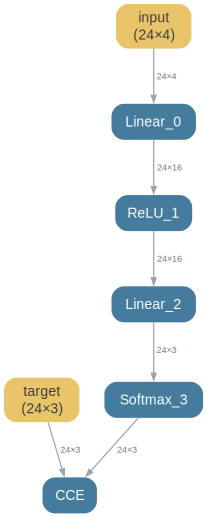

In [10]:
graph.draw_architecture()

## Vanishing gradients

Stacking many layers makes a network harder to train. During backprop, a gradient travels from the loss all the way back to the first layer, and at every layer it is scaled by that layer's weights. With small weights and enough depth, the signal reaching the earliest layers shrinks toward nothing — they barely learn. This is the **vanishing gradient** problem.

Build a deep stack of `Linear + ReLU` layers, run one forward/backward, and compare the gradient magnitude of each layer's weights from input to output.

In [11]:
W, depth = 16, 8
deep_layers = [Linear(4, W), ReLU()]
for _ in range(depth):
    deep_layers += [Linear(W, W), ReLU()]
deep_layers += [Linear(W, 3), Softmax()]
deep = Sequential(deep_layers)

deep_loss = CCE().forward(y, deep.forward(x))
deep_loss.backward()

# mean absolute weight-gradient of each Linear layer, input -> output
def grad_magnitude(layer):
    grads = layer.weights.grad
    return sum(abs(g) for g in grads) / len(grads)

linears = [layer for layer in deep.layers if isinstance(layer, Linear)]
magnitudes = [(layer.name, grad_magnitude(layer)) for layer in linears]
magnitudes

[('Linear_0', 2.036003363071916e-09),
 ('Linear_2', 4.230027809316192e-10),
 ('Linear_4', 6.663652355963894e-10),
 ('Linear_6', 1.450179161226775e-09),
 ('Linear_8', 6.282440772290349e-09),
 ('Linear_10', 3.848853661372261e-08),
 ('Linear_12', 2.666748255590199e-07),
 ('Linear_14', 1.6278084757814216e-06),
 ('Linear_16', 9.033180044409187e-06),
 ('Linear_18', 0.00023321080233691086)]

Plotted on a log axis, the gradient magnitude collapses by orders of magnitude as we move back toward the input.

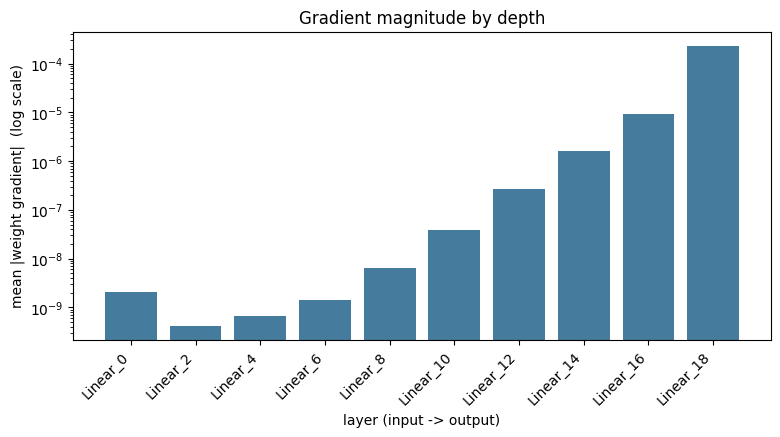

In [12]:
import matplotlib.pyplot as plt

names = [name for name, _ in magnitudes]
values = [m for _, m in magnitudes]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(values)), values, color="#457b9d")
ax.set_yscale("log")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_xlabel("layer (input -> output)")
ax.set_ylabel("mean |weight gradient|  (log scale)")
ax.set_title("Gradient magnitude by depth")
plt.show()

Read left (input) to right (output): the early layers receive a gradient many orders of magnitude smaller than the last layer's, so they learn far more slowly — if at all.

This is exactly what the rest of Phase 5 and Phase 6 address: better **weight initialization** (Xavier/He) keeps the gradient magnitude stable across depth, and **residual connections** give the gradient a shortcut path straight back to the early layers.